<a href="https://colab.research.google.com/github/eiyu18/pcvk/blob/main/week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from scipy import ndimage as ndi
from skimage import data, filters, color, segmentation, feature, morphology
from skimage.filters import gaussian
from skimage.segmentation import flood

/tmp/ipykernel_5221/3685979904.py:17: RuntimeWarning: invalid value encountered in divide
  mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)
/tmp/ipykernel_5221/3685979904.py:18: RuntimeWarning: invalid value encountered in divide
  muf = np.sum(intensity_arr[t:]*his[t:]) / float(pcf)


93


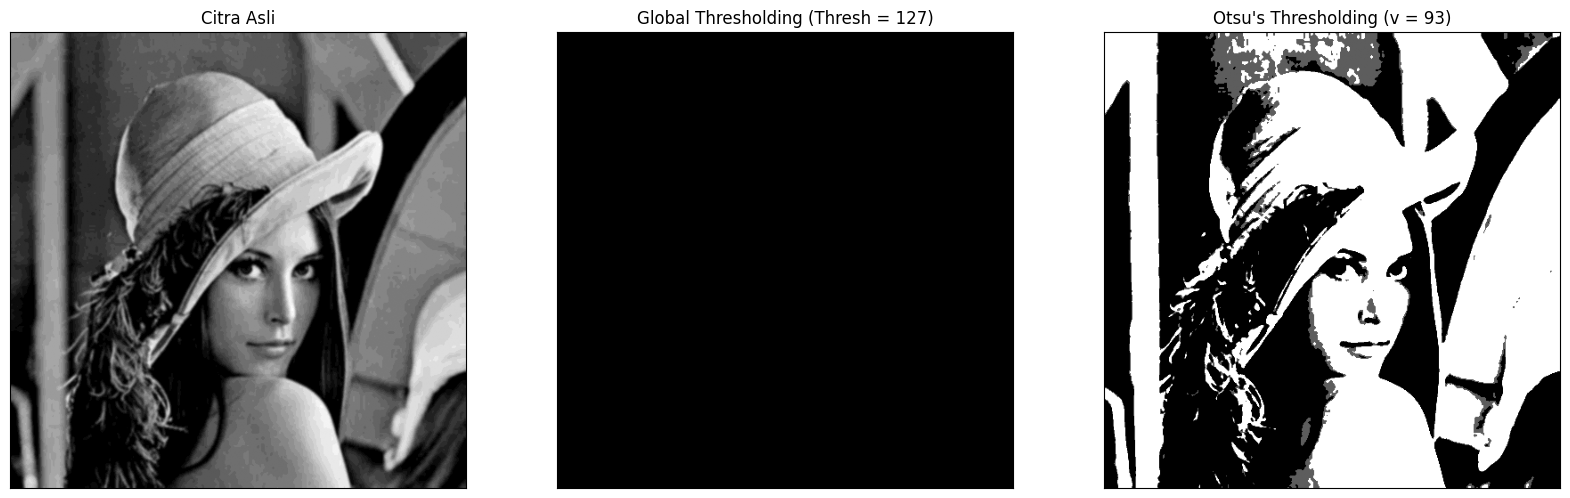

In [3]:
filename = ('/content/sample_data/lena_gs_lc2.jpg')
img = cv.imread(filename,0)
blur = cv.GaussianBlur(img,(5,5),0)
thresh=127
def otsu(gray):
  pixel_number = gray.shape[0] * gray.shape[1]
  mean_weight = 1.0/pixel_number
  his, bins = np.histogram(gray, np.arange(0,257))
  final_thresh = -1
  final_value = -1
  intensity_arr = np.arange(256)
  for t in bins[1:-1]:
      pcb = np.sum(his[:t])
      pcf = np.sum(his[t:])
      Wb = pcb * mean_weight
      Wf = pcf * mean_weight
      mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)
      muf = np.sum(intensity_arr[t:]*his[t:]) / float(pcf)
      value = Wb * Wf * (mub - muf) ** 2

      if value > final_value:
          final_thresh = t
          final_value = value
  final_img = gray.copy()
  print(final_thresh)
  final_img[gray > final_thresh] = 255
  final_img[gray < final_thresh] = 0
  return final_img, final_thresh

otsu_biner, otsu_thresh = otsu(blur)
x = ("Otsu's Thresholding (v = ")+str(otsu_thresh)+")"
ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)

titles = ['Citra Asli', 'Global Thresholding (Thresh = ' + str(thresh) +
')', x]
citra3 = [blur, th1, otsu_biner]

plt.figure(figsize = (20,15))
for i in range(len(citra3)):
    plt.subplot(1,3,i+1),plt.imshow(citra3[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

/tmp/ipykernel_5221/1582271143.py:17: RuntimeWarning: invalid value encountered in divide
  mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)


166


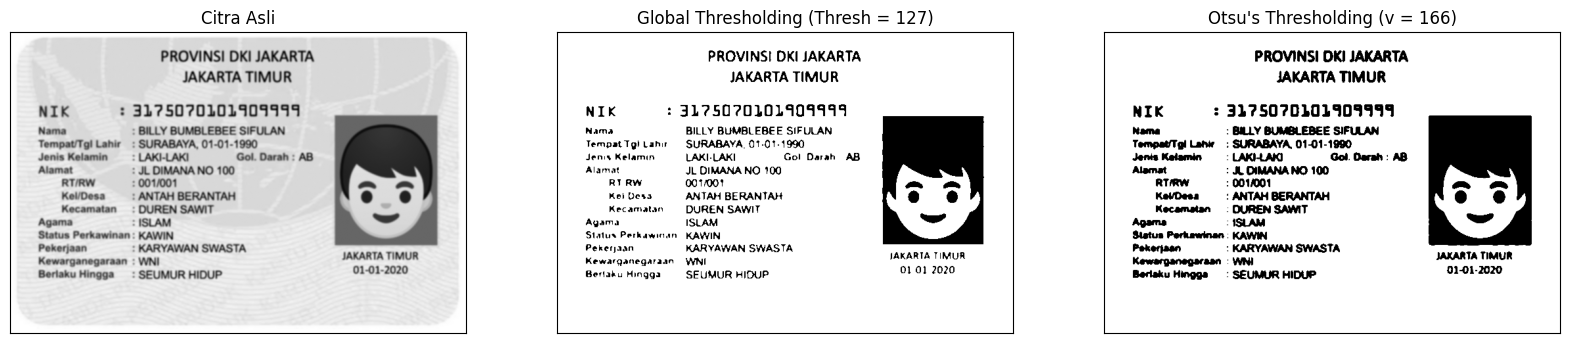

In [4]:
filename = ('/content/sample_data/ktp_fulan.jpg')
img = cv.imread(filename,0)
blur = cv.GaussianBlur(img,(5,5),0)
thresh=127
def otsu(gray):
  pixel_number = gray.shape[0] * gray.shape[1]
  mean_weight = 1.0/pixel_number
  his, bins = np.histogram(gray, np.arange(0,257))
  final_thresh = -1
  final_value = -1
  intensity_arr = np.arange(256)
  for t in bins[1:-1]:
      pcb = np.sum(his[:t])
      pcf = np.sum(his[t:])
      Wb = pcb * mean_weight
      Wf = pcf * mean_weight
      mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)
      muf = np.sum(intensity_arr[t:]*his[t:]) / float(pcf)
      value = Wb * Wf * (mub - muf) ** 2

      if value > final_value:
          final_thresh = t
          final_value = value
  final_img = gray.copy()
  print(final_thresh)
  final_img[gray > final_thresh] = 255
  final_img[gray < final_thresh] = 0
  return final_img, final_thresh

otsu_biner, otsu_thresh = otsu(blur)
x = ("Otsu's Thresholding (v = ")+str(otsu_thresh)+")"
ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)

titles = ['Citra Asli', 'Global Thresholding (Thresh = ' + str(thresh) +
')', x]
citra3 = [blur, th1, otsu_biner]

plt.figure(figsize = (20,15))
for i in range(len(citra3)):
    plt.subplot(1,3,i+1),plt.imshow(citra3[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

Min: 85 Max: 108
Pixels > 127: 0
Otsu threshold: 92.0


/tmp/ipykernel_5221/1372089536.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(blur.ravel(), 256, [0, 256], color='steelblue')


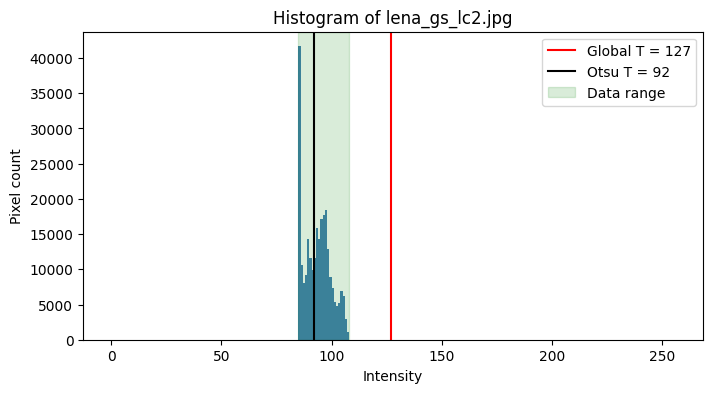

In [6]:
filename = '/content/sample_data/lena_gs_lc2.jpg'
img = cv.imread(filename, 0)
blur = cv.GaussianBlur(img, (5, 5), 0)

ret2, _ = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

print("Min:", blur.min(), "Max:", blur.max())
print("Pixels > 127:", np.sum(blur > 127))
print("Otsu threshold:", ret2)

plt.figure(figsize=(8, 4))
plt.hist(blur.ravel(), 256, [0, 256], color='steelblue')
plt.axvline(127, color='red', label='Global T = 127')
plt.axvline(ret2, color='black', label=f'Otsu T = {ret2:.0f}')
plt.axvspan(blur.min(), blur.max(), color='green', alpha=0.15, label='Data range')
plt.xlabel('Intensity')
plt.ylabel('Pixel count')
plt.title('Histogram of lena_gs_lc2.jpg')
plt.legend()
plt.show()

Min: 15 Max: 255
Pixels > 127: 281184
Otsu threshold: 165.0


/tmp/ipykernel_5221/3248738692.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(blur.ravel(), 256, [0, 256], color='steelblue')


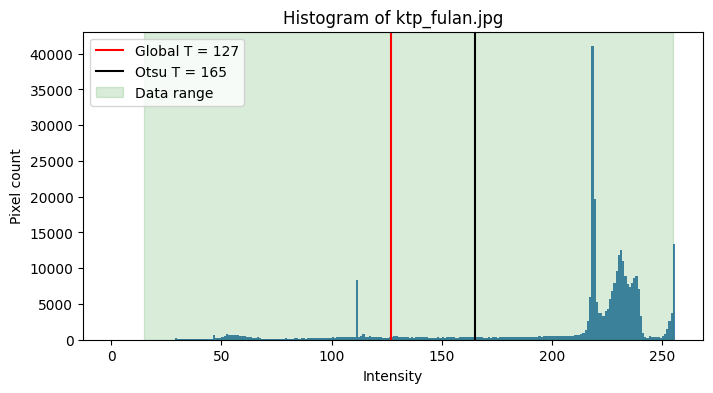

In [7]:
filename = '/content/sample_data/ktp_fulan.jpg'
img = cv.imread(filename, 0)
blur = cv.GaussianBlur(img, (5, 5), 0)

ret2, _ = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

print("Min:", blur.min(), "Max:", blur.max())
print("Pixels > 127:", np.sum(blur > 127))
print("Otsu threshold:", ret2)

plt.figure(figsize=(8, 4))
plt.hist(blur.ravel(), 256, [0, 256], color='steelblue')
plt.axvline(127, color='red', label='Global T = 127')
plt.axvline(ret2, color='black', label=f'Otsu T = {ret2:.0f}')
plt.axvspan(blur.min(), blur.max(), color='green', alpha=0.15, label='Data range')
plt.xlabel('Intensity')
plt.ylabel('Pixel count')
plt.title('Histogram of ktp_fulan.jpg')
plt.legend()
plt.show()

In [12]:
gray = data.coins()
seed = (121, 63)

region = flood(
    gray,
    seed_point=seed,
    tolerance=20,
    connectivity=1
)

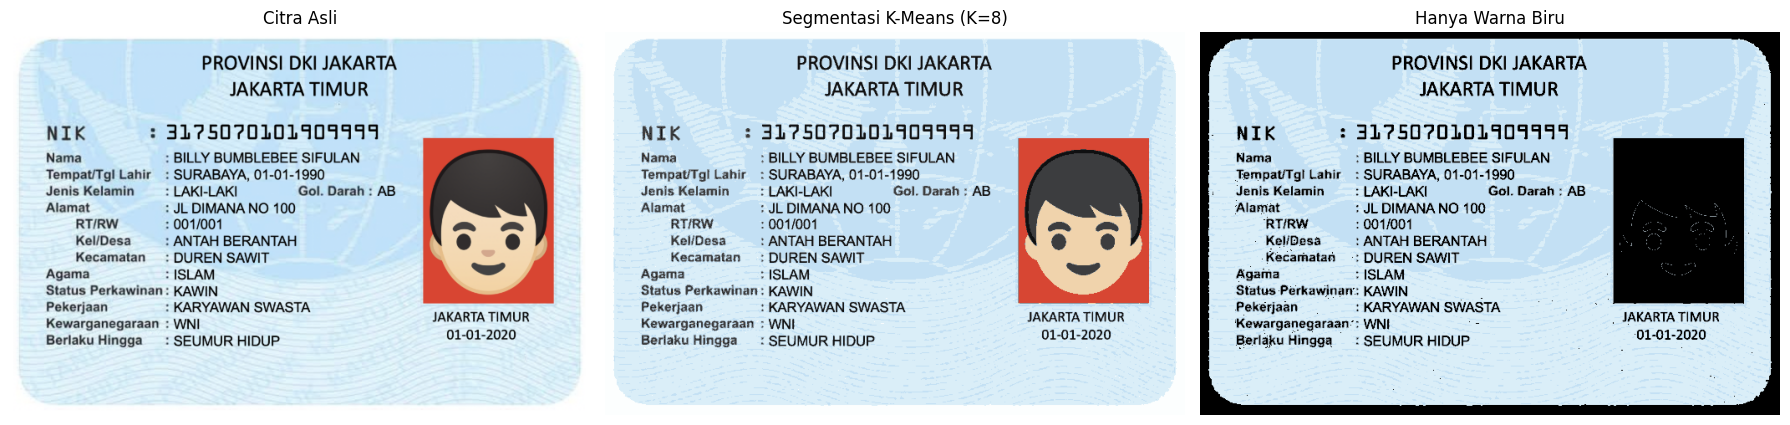

Blue pixels: 247407 of 317852
Cluster centers (RGB):
0 [60 61 63] HSV [110  12  63] 
1 [218 238 248] HSV [100  31 248] BLUE
2 [215  70  51] HSV [  3 195 215] 
3 [15 16 17] HSV [105  30  17] 
4 [138 149 157] HSV [103  31 157] BLUE
5 [240 211 172] HSV [ 17  72 240] 
6 [252 254 254] HSV [ 90   2 254] 
7 [195 224 244] HSV [102  51 244] BLUE


In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

filename = '/content/sample_data/ktp_fulan.jpg'
img = cv.cvtColor(cv.imread(filename), cv.COLOR_BGR2RGB)

Z = np.float32(img.reshape((-1, 3)))
k = 8
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(Z)

labels = kmeans.labels_
centers = np.uint8(kmeans.cluster_centers_)
segmented = centers[labels].reshape(img.shape)

hsv = cv.cvtColor(segmented, cv.COLOR_RGB2HSV)
H, S, V = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

kelompok_biru = np.where((H >= 85) & (H <= 130) & (S >= 25) & (V >= 40))

mask = np.zeros(img.shape[:2], dtype=bool)
mask[kelompok_biru] = True

only_blue = np.zeros_like(segmented)
only_blue[mask] = segmented[mask]

titles = ['Citra Asli', f'Segmentasi K-Means (K={k})', 'Hanya Warna Biru']
images = [img, segmented, only_blue]

plt.figure(figsize=(18, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

print('Blue pixels:', mask.sum(), 'of', mask.size)
print('Cluster centers (RGB):')
for i, c in enumerate(centers):
    hc = cv.cvtColor(c.reshape(1, 1, 3), cv.COLOR_RGB2HSV)[0, 0]
    is_blue = 85 <= hc[0] <= 130 and hc[1] >= 25 and hc[2] >= 40
    print(i, c, 'HSV', hc, 'BLUE' if is_blue else '')